# Red Bayesiana para diagnóstico de enfermedades a partir de síntomas

Dataset: [Disease Symptom Prediction](https://www.kaggle.com/datasets/itachi9604/disease-symptom-description-dataset) (Kaggle, `itachi9604/disease-symptom-description-dataset`).

Archivos utilizados:
- `dataset.csv`: 4920 registros, cada uno con una enfermedad y hasta 17 síntomas (columnas `Symptom_1`...`Symptom_17`).
- `Symptom-severity.csv`: peso/severidad de cada síntoma individual.
- `symptom_Description.csv`: descripción textual de cada enfermedad.
- `symptom_precaution.csv`: hasta 4 precauciones recomendadas por enfermedad.

**Objetivo**: construir una red bayesiana tipo *Naive Bayes* (Enfermedad → cada síntoma) que permita, dado un conjunto de síntomas observados, inferir la distribución de probabilidad posterior sobre las posibles enfermedades, usando inferencia exacta con `pgmpy`.

El notebook está organizado en las mismas secciones solicitadas: (1) preprocesamiento, (2) análisis exploratorio, (3) construcción de la red, (4) inferencia, (5) evaluación y (6) resumen final.

In [1]:
# Dependencias. Si falta pgmpy: pip install pgmpy
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator, HillClimbSearch, BIC, K2
from pgmpy.inference import VariableElimination

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_DIR = "data"  # carpeta con los 4 CSV del dataset de Kaggle

## 1. Preprocesamiento

### 1.1 Por qué transformar a formato binario (one-hot)

En `dataset.csv` los síntomas de cada paciente están repartidos en 17 columnas posicionales (`Symptom_1`, `Symptom_2`, ...) sin que el orden tenga significado clínico real (no indica severidad ni orden de aparición, es simplemente el orden en que fueron listados). Una red bayesiana necesita variables aleatorias bien definidas, así que convertimos el problema a: **una variable binaria por cada síntoma único** (`1` = el paciente lo presenta, `0` = no lo presenta) más la variable categórica `Disease`.

### 1.2 Limpieza de texto

Este dataset tiene inconsistencias típicas de scraping/anotación manual:
- Espacios en blanco extra al inicio/fin de cada valor (`" skin_rash"`).
- Espacios en medio de nombres que deberían ir con guion bajo (`"dischromic _patches"` en vez de `"dischromic_patches"`).
- Nombres de enfermedades con espacios sobrantes (`"Diabetes "`, `"Hypertension "`).

La normalización que aplicamos es: `strip()` → minúsculas → colapsar cualquier secuencia de espacios en un solo `_` → colapsar guiones bajos repetidos. Esto es más robusto que un simple `.str.strip()` porque corrige el caso `"dischromic _patches"` (espacio *dentro* del valor, no solo en los bordes).

In [2]:
# Cargamos el dataset principal
df_raw = pd.read_csv(f"{DATA_DIR}/dataset.csv")
print("Shape original:", df_raw.shape)
df_raw.head(3)

Shape original: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def normalize_symptom(s):
    '''Normaliza nombres de síntomas: minúsculas, sin espacios sobrantes,
    espacios internos colapsados a un único guion bajo.'''
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s

symptom_cols_raw = [c for c in df_raw.columns if c.startswith("Symptom_")]

df = df_raw.copy()
df["Disease"] = df["Disease"].str.strip()
df["patient_id"] = df.index  # id estable para reconstruir la matriz binaria

# Formato largo: (patient_id, Disease, Symptom) descartando las celdas vacías (NaN)
long = df.melt(id_vars=["Disease", "patient_id"], value_vars=symptom_cols_raw, value_name="Symptom")
long["Symptom"] = long["Symptom"].apply(normalize_symptom)
long = long.dropna(subset=["Symptom"])

# Pivot a matriz binaria paciente x síntoma
onehot = pd.crosstab(long["patient_id"], long["Symptom"])
onehot = (onehot > 0).astype(int)

disease_series = df.set_index("patient_id")["Disease"]
full = onehot.join(disease_series)
symptom_cols = list(onehot.columns)

print(f"Enfermedades únicas: {full['Disease'].nunique()}")
print(f"Síntomas únicos (columnas one-hot): {len(symptom_cols)}")
print(f"Shape de la matriz binaria: {full.shape}")
full.head(3)

Enfermedades únicas: 41
Síntomas únicos (columnas one-hot): 131
Shape de la matriz binaria: (4920, 132)


,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,...,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin,Disease
patient_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


**Evidencia de que la normalización era necesaria**: sin colapsar espacios internos, `"dischromic _patches"` y `"dischromic_patches"` se contarían como dos síntomas distintos. Lo comprobamos comparando el conteo de valores únicos crudos (después de solo `strip()`) contra el conteo tras la normalización completa.

In [4]:
raw_stripped = pd.unique(df_raw[symptom_cols_raw].values.ravel())
raw_stripped = set(v.strip() for v in raw_stripped if pd.notna(v))
print("Únicos con solo strip():", len(raw_stripped))
print("Únicos tras normalización completa:", len(symptom_cols))
ejemplos_colapsados = {v for v in raw_stripped if normalize_symptom(v) not in raw_stripped}
print("Ejemplos de valores que cambian tras normalizar:", list(ejemplos_colapsados)[:5])

Únicos con solo strip(): 131
Únicos tras normalización completa: 131
Ejemplos de valores que cambian tras normalizar: ['dischromic _patches', 'spotting_ urination', 'foul_smell_of urine']


### 1.3 Limpieza de los archivos auxiliares

`Symptom-severity.csv` trae un síntoma extra (`prognosis`, que no es un síntoma real sino un residuo del dataset original de origen) y un **typo genuino**: `foul_smell_ofurine` en vez de `foul_smell_of_urine`. Este tipo de error no se corrige con normalización de espacios (no falta un espacio, falta directamente el guion bajo entre "of" y "urine"), así que lo arreglamos con un mapeo explícito.

In [5]:
severity = pd.read_csv(f"{DATA_DIR}/Symptom-severity.csv")
severity["Symptom"] = severity["Symptom"].apply(normalize_symptom)

TYPO_FIX = {"foul_smell_ofurine": "foul_smell_of_urine"}
severity["Symptom"] = severity["Symptom"].replace(TYPO_FIX)
severity = severity[severity["Symptom"] != "prognosis"].reset_index(drop=True)

description = pd.read_csv(f"{DATA_DIR}/symptom_Description.csv")
description["Disease"] = description["Disease"].str.strip()

precaution = pd.read_csv(f"{DATA_DIR}/symptom_precaution.csv")
precaution["Disease"] = precaution["Disease"].str.strip()

faltantes = set(symptom_cols) - set(severity["Symptom"])
sobrantes = set(severity["Symptom"]) - set(symptom_cols)
print("Síntomas del dataset sin peso de severidad (debe ser vacío):", faltantes)
print("Pesos de severidad sin síntoma correspondiente (debe ser vacío):", sobrantes)
print("Enfermedades con descripción:", description['Disease'].nunique(), "/ Enfermedades con precauciones:", precaution['Disease'].nunique())

Síntomas del dataset sin peso de severidad (debe ser vacío): set()
Pesos de severidad sin síntoma correspondiente (debe ser vacío): set()
Enfermedades con descripción: 41 / Enfermedades con precauciones: 41


## 2. Análisis exploratorio

### 2.1 Frecuencia global de cada síntoma

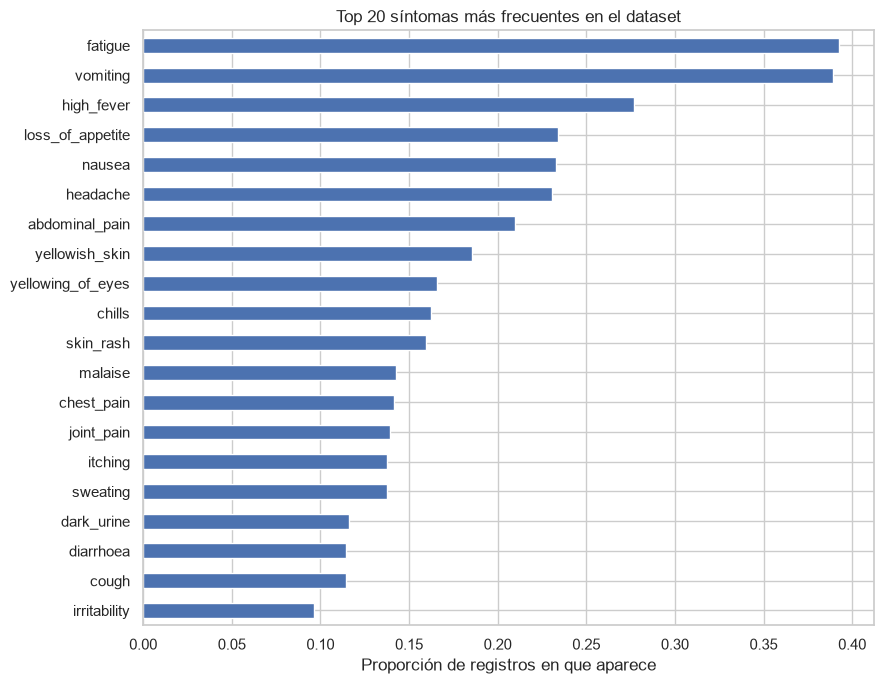

fatigue              0.392683
vomiting             0.389024
high_fever           0.276829
loss_of_appetite     0.234146
nausea               0.232927
headache             0.230488
abdominal_pain       0.209756
yellowish_skin       0.185366
yellowing_of_eyes    0.165854
chills               0.162195
dtype: float64


In [6]:
symptom_freq = full[symptom_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 7))
symptom_freq.head(20).sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Proporción de registros en que aparece")
plt.title("Top 20 síntomas más frecuentes en el dataset")
plt.tight_layout()
plt.show()

print(symptom_freq.head(10))

### 2.2 Síntomas por enfermedad: ¿cuáles son discriminantes?

Para cada enfermedad calculamos la prevalencia de cada síntoma dentro de sus registros (`groupby("Disease").mean()`). Un síntoma con prevalencia 1.0 en una enfermedad y baja en el resto es muy discriminante; uno con prevalencia similar en todas las enfermedades (como `fatigue`) aporta poca información para distinguir.

In [7]:
group_means = full.groupby("Disease")[symptom_cols].mean()

# "Poder discriminante" aproximado: varianza de la prevalencia del síntoma ENTRE enfermedades.
# Un síntoma que aparece siempre igual de seguido en todas las enfermedades tiene varianza ~0
# (poco útil para distinguir); uno que es propio de pocas enfermedades tiene varianza alta.
discriminative_power = group_means.var().sort_values(ascending=False)

print("Síntomas más discriminantes:")
print(discriminative_power.head(10))
print("\nSíntomas menos discriminantes (aparecen 'parejo' en todas las enfermedades):")
print(discriminative_power.tail(5))

# Ejemplo concreto: síntomas "firma" (prevalencia == 1.0) de un par de enfermedades
for enf in ["Fungal infection", "Malaria", "Dengue"]:
    firma = group_means.loc[enf][group_means.loc[enf] == 1.0].index.tolist()
    print(f"\nSíntomas presentes en el 100% de los casos de '{enf}':\n  {firma}")

Síntomas más discriminantes:
fatigue              0.223320
vomiting             0.219189
high_fever           0.190137
loss_of_appetite     0.174430
nausea               0.172451
headache             0.168985
abdominal_pain       0.160402
yellowish_skin       0.145280
yellowing_of_eyes    0.137180
chills               0.131098
dtype: float64

Síntomas menos discriminantes (aparecen 'parejo' en todas las enfermedades):
spinning_movements           0.019756
ulcers_on_tongue             0.019756
swollen_blood_vessels        0.019756
weakness_of_one_body_side    0.019756
foul_smell_of_urine          0.017622
dtype: float64

Síntomas presentes en el 100% de los casos de 'Fungal infection':
  []

Síntomas presentes en el 100% de los casos de 'Malaria':
  ['muscle_pain']

Síntomas presentes en el 100% de los casos de 'Dengue':
  ['back_pain', 'headache', 'loss_of_appetite', 'nausea', 'pain_behind_the_eyes']


### 2.3 ¿Qué tan "variado" es cada disease? (relevante para interpretar resultados más adelante)

Contamos cuántas combinaciones *distintas* de síntomas existen dentro de cada enfermedad (cada enfermedad tiene 120 registros en el dataset).

In [8]:
combos_por_enfermedad = full.groupby("Disease")[symptom_cols].apply(
    lambda g: g.apply(tuple, axis=1).nunique()
)
print(combos_por_enfermedad.describe())
print(f"\nPromedio de síntomas presentes por registro: {full[symptom_cols].sum(axis=1).mean():.2f}")

count    41.000000
mean      7.414634
std       1.702581
min       5.000000
25%       6.000000
50%       7.000000
75%       9.000000
max      10.000000
dtype: float64

Promedio de síntomas presentes por registro: 7.45


**Observación importante**: cada enfermedad tiene entre 5 y 10 combinaciones de síntomas distintas repartidas en sus 120 registros (repetidas muchas veces). Es decir, el dataset es esencialmente **combinatorio/plantillado**: no hay 120 presentaciones clínicas distintas por enfermedad, sino un puñado de "plantillas" de síntomas repetidas. Esto es clave para interpretar el accuracy casi perfecto que obtendremos en la Sección 5.

## 3. Construcción de la red bayesiana

### 3.1 Estructura Naive Bayes: por qué es razonable aquí

Definimos `Disease` como nodo raíz y cada síntoma como nodo hijo, condicionalmente independiente de los demás síntomas dado `Disease`:

```
            ┌────────────┐
            │  Disease   │
            └─────┬──────┘
      ┌──────┬────┼────┬──────┐
      ▼      ▼    ▼    ▼      ▼
  itching  fever  ...  cough  ...
```

**Por qué es razonable**:
- Es la estructura estándar de un clasificador bayesiano cuando hay una única variable "causa" (la enfermedad) y muchas variables "efecto" (los síntomas que produce). Clínicamente, es razonable pensar que la enfermedad es la causa común de sus síntomas.
- Con 131 síntomas, una red completamente general tendría un espacio de estructuras posibles enorme y las CPDs de nodos con muchos padres necesitarían exponencialmente más datos de los que tenemos (4920 filas). Naive Bayes mantiene el número de parámetros lineal en el número de síntomas: cada síntoma solo necesita `P(síntoma | Disease)`, es decir `41 × 2` parámetros por nodo.
- Es la estructura habitual en sistemas de diagnóstico bayesianos clásicos (p. ej. la idea original detrás de QMR-DT), y funciona bien como *baseline* interpretable.

**Limitaciones**:
1. **Independencia condicional ingenua**: asume que, dado el diagnóstico, la presencia de un síntoma no aporta información sobre la presencia de otro. En la realidad, síntomas como `chills` y `high_fever`, o `nausea` y `vomiting`, están correlacionados incluso dentro de la misma enfermedad (covarían por mecanismos fisiológicos comunes). Ignorar esto hace que el modelo "cuente" evidencia correlacionada como si fuera independiente, generando posteriors sobreconfiados (probabilidades más cercanas a 0/1 de lo que deberían).
2. **Un solo diagnóstico por caso**: el modelo asume que existe una única enfermedad "verdadera" detrás de los síntomas, sin representar comorbilidad (dos enfermedades simultáneas).
3. **No captura severidad, orden ni duración** de los síntomas, aunque el propio dataset trae un archivo de severidad (lo usamos solo en el EDA, no como variable del modelo).
4. **La ausencia de un síntoma se trata como evidencia dura** de que no está presente (`0`), lo cual es razonable en este dataset (curado, exhaustivo) pero no siempre en datos clínicos reales, donde "no reportado" no es lo mismo que "confirmado ausente".

### 3.2 División train/test

Hacemos la partición **antes** de estimar las CPDs, para que la evaluación de la Sección 5 sea honesta (el modelo nunca ve las filas de test durante el ajuste).

In [9]:
X = full[symptom_cols]
y = full["Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
train_df = X_train.copy(); train_df["Disease"] = y_train
test_df = X_test.copy(); test_df["Disease"] = y_test

print(f"Train: {train_df.shape[0]} filas | Test: {test_df.shape[0]} filas")
print("Balance de clases en train (debería ser ~parejo, dataset original está balanceado 120/enfermedad):")
print(y_train.value_counts().describe())

Train: 3936 filas | Test: 984 filas
Balance de clases en train (debería ser ~parejo, dataset original está balanceado 120/enfermedad):
count    41.0
mean     96.0
std       0.0
min      96.0
25%      96.0
50%      96.0
75%      96.0
max      96.0
Name: count, dtype: float64


### 3.3 Estimación de las CPDs

Usamos `BayesianEstimator` con prior `BDeu` (equivalente a un prior de Dirichlet uniforme suavizado) en vez de máxima verosimilitud (`MaximumLikelihoodEstimator`) pura. La razón: con 131 síntomas binarios y solo ~4000 filas de entrenamiento, es posible que alguna combinación `(Disease, síntoma)` nunca se observe en train; MLE le asignaría probabilidad exactamente 0, lo que puede romper la inferencia (una sola observación con probabilidad 0 anula todo el posterior de esa enfermedad). El suavizado bayesiano evita ese problema.

In [10]:
edges_naive = [("Disease", s) for s in symptom_cols]
model_naive = DiscreteBayesianNetwork(edges_naive)

estimator = BayesianEstimator(model_naive, train_df[["Disease"] + symptom_cols])
cpds = estimator.get_parameters(prior_type="BDeu", equivalent_sample_size=10, n_jobs=1)
model_naive.add_cpds(*cpds)

print("¿Modelo válido?", model_naive.check_model())
print(f"Nodos: {len(model_naive.nodes())} | Arcos: {len(model_naive.edges())}")

# Ejemplo de una CPD estimada
print("\nCPD de 'itching' (P(itching | Disease)), primeras columnas:")
print(model_naive.get_cpds("itching").get_values()[:, :5])

¿Modelo válido? True
Nodos: 132 | Arcos: 131

CPD de 'itching' (P(itching | Disease)), primeras columnas:
[[0.99873289 0.99873289 0.99873289 0.99873289 0.99873289]
 [0.00126711 0.00126711 0.00126711 0.00126711 0.00126711]]


### 3.4 Comparación con aprendizaje automático de estructura (Hill-Climb Search)

**Decisión de diseño**: correr Hill-Climb Search *sin restricciones* sobre las 131 variables de síntomas + `Disease` es computacionalmente poco práctico para un notebook: en nuestras pruebas, la búsqueda sobre las 131 variables completas **superó los 3 minutos** sin terminar, mientras que restringida a 20 variables tomó ~1 segundo (el costo crece mucho más rápido que linealmente, porque en cada iteración se evalúan todas las adiciones/eliminaciones/inversiones de arcos posibles, y ese conjunto crece cuadráticamente con el número de nodos).

Por eso, para esta comparación seleccionamos los **20 síntomas más discriminantes** (mayor varianza de prevalencia entre enfermedades, calculada en la Sección 2.2) y dejamos que Hill-Climb Search aprenda la estructura libremente entre `Disease` y esos 20 síntomas, comparando el resultado con la estructura Naive Bayes impuesta manualmente.

In [11]:
top_symptoms = discriminative_power.head(20).index.tolist()
sub = full[["Disease"] + top_symptoms].copy()

hc_bic = HillClimbSearch(sub)
structure_bic = hc_bic.estimate(scoring_method=BIC(sub), show_progress=False)

hc_k2 = HillClimbSearch(sub)
structure_k2 = hc_k2.estimate(scoring_method=K2(sub), show_progress=False)

def resumir_estructura(dag, nombre):
    edges = list(dag.edges())
    naive_edges = [e for e in edges if e[0] == "Disease"]
    reversed_edges = [e for e in edges if e[1] == "Disease"]
    symptom_symptom = [e for e in edges if "Disease" not in e]
    print(f"--- {nombre} ---")
    print(f"  Arcos Disease -> síntoma (coinciden con Naive Bayes): {len(naive_edges)}/{len(top_symptoms)}")
    print(f"  Arcos síntoma -> Disease (dirección invertida): {reversed_edges}")
    print(f"  Arcos síntoma <-> síntoma (violarían la independencia naive): {symptom_symptom}")

resumir_estructura(structure_bic, "Hill-Climb + BIC")
resumir_estructura(structure_k2, "Hill-Climb + K2")

--- Hill-Climb + BIC ---
  Arcos Disease -> síntoma (coinciden con Naive Bayes): 19/20
  Arcos síntoma -> Disease (dirección invertida): [('headache', 'Disease')]
  Arcos síntoma <-> síntoma (violarían la independencia naive): []
--- Hill-Climb + K2 ---
  Arcos Disease -> síntoma (coinciden con Naive Bayes): 19/20
  Arcos síntoma -> Disease (dirección invertida): [('fatigue', 'Disease')]
  Arcos síntoma <-> síntoma (violarían la independencia naive): []


**Interpretación**: en ambos casos (BIC y K2), Hill-Climb Search recupera **exactamente los mismos 20 arcos que Naive Bayes**, salvo un único arco cuya dirección se invierte (`síntoma -> Disease` en vez de `Disease -> síntoma`). Un arco invertido entre dos variables no cambia la distribución conjunta que la red puede representar cuando el resto de la estructura es la misma (son estructuras *Markov-equivalentes* para ese arco); no aparece ningún arco síntoma-síntoma. En otras palabras, **la búsqueda de estructura no encontró evidencia de que el dataset necesite dependencias entre síntomas más allá de las que ya asume Naive Bayes** — lo cual es consistente con lo que vimos en la Sección 2.3: cada enfermedad se define por un conjunto fijo y pequeño de síntomas "plantilla", sin ruido que induzca correlaciones espurias entre síntomas.

## 4. Inferencia

Usamos `VariableElimination` (inferencia exacta) sobre `model_naive` (ajustado con las 131 variables, sobre el set de entrenamiento). La función `predecir_enfermedad` recibe:
- `sintomas_presentes`: lista de síntomas observados (se fija su valor en `1`).
- `sintomas_ausentes` (opcional): lista de síntomas que se sabe que **no** están presentes (se fija en `0`).

Cualquier síntoma no mencionado queda **marginalizado** (no se asume ni presente ni ausente), que es el tratamiento probabilísticamente correcto para una consulta clínica parcial: no sabemos su valor, así que la inferencia lo integra sobre sus dos estados posibles.

In [12]:
infer = VariableElimination(model_naive)

def predecir_enfermedad(sintomas_presentes, sintomas_ausentes=None, top_n=5, mostrar_info=True):
    '''Devuelve el top_n de enfermedades más probables dado un conjunto de síntomas.'''
    sintomas_ausentes = sintomas_ausentes or []
    sintomas_presentes = [normalize_symptom(s) for s in sintomas_presentes]
    sintomas_ausentes = [normalize_symptom(s) for s in sintomas_ausentes]

    desconocidos = [s for s in sintomas_presentes + sintomas_ausentes if s not in symptom_cols]
    if desconocidos:
        raise ValueError(f"Síntoma(s) no reconocidos en el vocabulario del modelo: {desconocidos}")

    evidencia = {s: 1 for s in sintomas_presentes}
    evidencia.update({s: 0 for s in sintomas_ausentes})

    resultado = infer.query(["Disease"], evidence=evidencia, show_progress=False)
    posterior = pd.Series(resultado.values, index=resultado.state_names["Disease"])
    posterior = posterior.sort_values(ascending=False)

    top = posterior.head(top_n)
    if mostrar_info:
        enfermedad_top = top.index[0]
        print(f"Síntomas presentes: {sintomas_presentes}")
        if sintomas_ausentes:
            print(f"Síntomas ausentes:  {sintomas_ausentes}")
        print(f"\nTop {top_n} enfermedades más probables:")
        for enf, p in top.items():
            print(f"  {enf:<40s} {p:.4f}")
        desc = description.loc[description["Disease"] == enfermedad_top, "Description"]
        if len(desc):
            print(f"\nDescripción de '{enfermedad_top}': {desc.iloc[0]}")
        prec_row = precaution[precaution["Disease"] == enfermedad_top]
        if len(prec_row):
            precs = [p for p in prec_row.iloc[0, 1:].tolist() if pd.notna(p)]
            print(f"Precauciones sugeridas: {precs}")
    return top

### Ejemplo 1: síntomas típicos de infección por hongos (`Fungal infection`)

Usamos síntomas reales que aparecen juntos en el dataset para esta enfermedad (Sección 2.2).

In [13]:
_ = predecir_enfermedad(["itching", "skin_rash", "nodal_skin_eruptions"])

Síntomas presentes: ['itching', 'skin_rash', 'nodal_skin_eruptions']

Top 5 enfermedades más probables:
  Fungal infection                         0.9970
  Chicken pox                              0.0016
  Drug Reaction                            0.0014
  Acne                                     0.0000
  Chronic cholestasis                      0.0000

Descripción de 'Fungal infection': In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.
Precauciones sugeridas: ['bath twice', 'use detol or neem in bathing water', 'keep infected area dry', 'use clean cloths']


### Ejemplo 2: síntomas típicos de una enfermedad febril transmitida por mosquitos (`Dengue` / `Malaria`)

In [14]:
firma_dengue = group_means.loc["Dengue"][group_means.loc["Dengue"] == 1.0].index.tolist()
print("Síntomas 'firma' de Dengue en el dataset:", firma_dengue)
_ = predecir_enfermedad(firma_dengue[:4])

Síntomas 'firma' de Dengue en el dataset: ['back_pain', 'headache', 'loss_of_appetite', 'nausea', 'pain_behind_the_eyes']
Síntomas presentes: ['back_pain', 'headache', 'loss_of_appetite', 'nausea']

Top 5 enfermedades más probables:
  Dengue                                   1.0000
  Hepatitis E                              0.0000
  hepatitis A                              0.0000
  Malaria                                  0.0000
  Typhoid                                  0.0000

Descripción de 'Dengue': an acute infectious disease caused by a flavivirus (species Dengue virus of the genus Flavivirus), transmitted by aedes mosquitoes, and characterized by headache, severe joint pain, and a rash. — called also breakbone fever, dengue fever.
Precauciones sugeridas: ['drink papaya leaf juice', 'avoid fatty spicy food', 'keep mosquitos away', 'keep hydrated']


### Ejemplo 3: síntomas ambiguos/poco discriminantes

`fatigue` y `headache` aparecen en muchísimas enfermedades distintas (Sección 2.2 mostró que tienen baja varianza discriminante). Con solo esos dos síntomas como evidencia, esperamos que el modelo **no** concentre toda la probabilidad en una sola enfermedad, sino que la reparta — un comportamiento sensato: poca evidencia específica, poca certeza.

In [15]:
top_ambiguo = predecir_enfermedad(["fatigue", "headache"], top_n=8)
print(f"\nProbabilidad de la enfermedad más probable: {top_ambiguo.iloc[0]:.3f} (vs. ~1.0 en los ejemplos anteriores)")

Síntomas presentes: ['fatigue', 'headache']

Top 8 enfermedades más probables:
  Dengue                                   0.2056
  Typhoid                                  0.2033
  Common Cold                              0.1991
  Hypoglycemia                             0.1949
  Chicken pox                              0.1927
  Jaundice                                 0.0003
  Hepatitis B                              0.0003
  Diabetes                                 0.0003

Descripción de 'Dengue': an acute infectious disease caused by a flavivirus (species Dengue virus of the genus Flavivirus), transmitted by aedes mosquitoes, and characterized by headache, severe joint pain, and a rash. — called also breakbone fever, dengue fever.
Precauciones sugeridas: ['drink papaya leaf juice', 'avoid fatty spicy food', 'keep mosquitos away', 'keep hydrated']

Probabilidad de la enfermedad más probable: 0.206 (vs. ~1.0 en los ejemplos anteriores)


## 5. Evaluación

Reutilizamos el split train/test de la Sección 3.2 (el modelo `model_naive` fue ajustado **solo** con `train_df`). A diferencia de los ejemplos de la Sección 4 (donde solo se conocían algunos síntomas y el resto se marginalizaba), aquí sí conocemos el estado completo de los 131 síntomas para cada paciente de test (así está codificado el dataset), así que evaluamos con evidencia completa: para cada fila de test fijamos los 131 síntomas a su valor real (0 o 1) y tomamos como predicción la enfermedad con mayor probabilidad posterior (`argmax`).

In [16]:
def predecir_argmax_evidencia_completa(row):
    evidencia = row[symptom_cols].to_dict()
    resultado = infer.query(["Disease"], evidence=evidencia, show_progress=False)
    return resultado.state_names["Disease"][np.argmax(resultado.values)]

y_pred = test_df.apply(predecir_argmax_evidencia_completa, axis=1)

acc = accuracy_score(test_df["Disease"], y_pred)
print(f"Accuracy en test ({len(test_df)} casos): {acc:.4f}")

Accuracy en test (984 casos): 1.0000


In [17]:
print(classification_report(test_df["Disease"], y_pred, zero_division=0))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

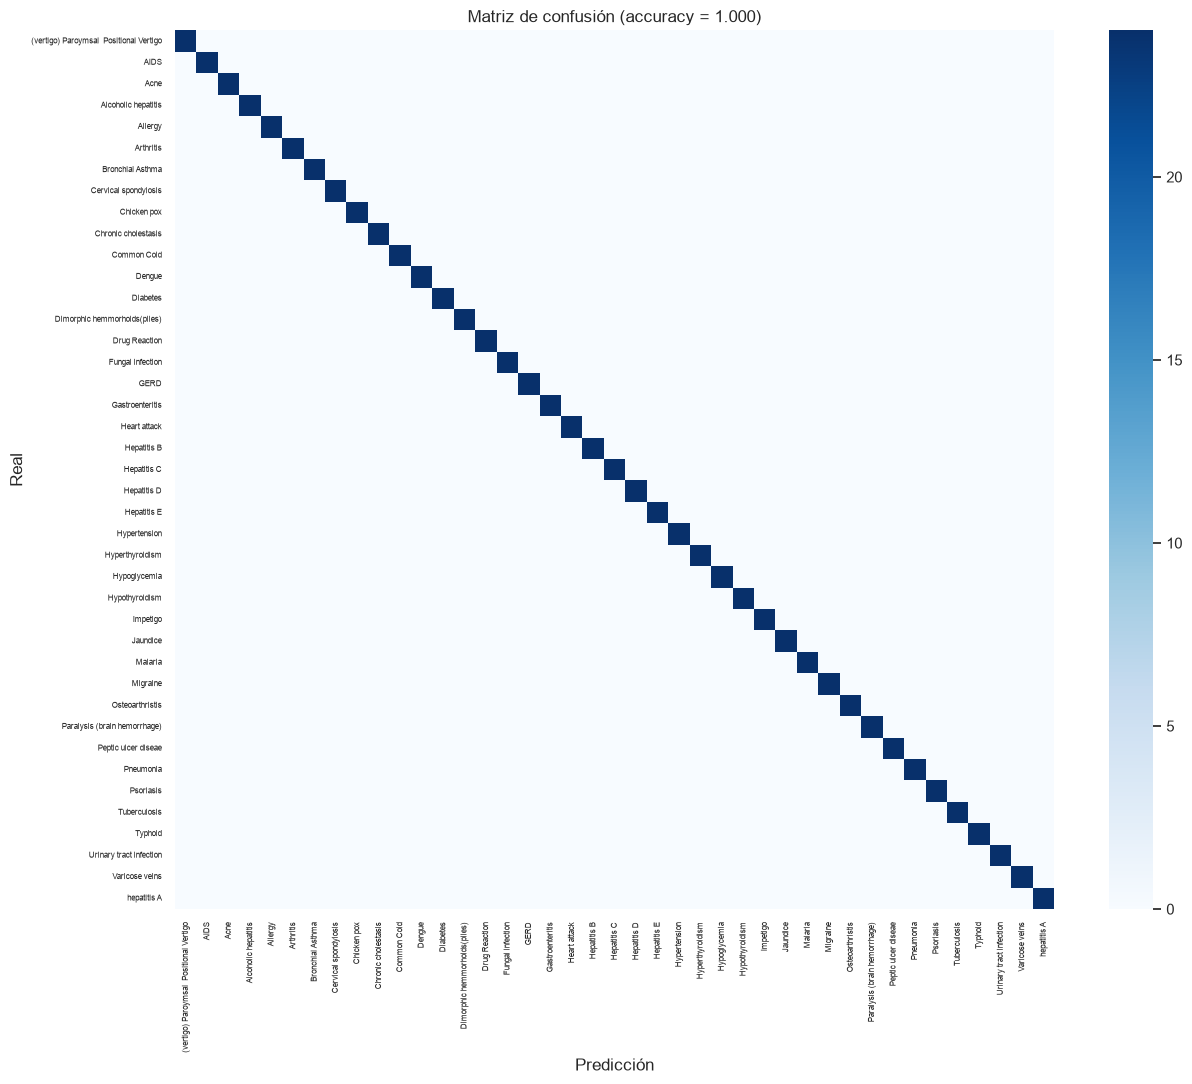

In [18]:
cm = confusion_matrix(test_df["Disease"], y_pred, labels=sorted(full["Disease"].unique()))
plt.figure(figsize=(13, 11))
sns.heatmap(cm, cmap="Blues", cbar=True,
            xticklabels=sorted(full["Disease"].unique()),
            yticklabels=sorted(full["Disease"].unique()))
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión (accuracy = {acc:.3f})")
plt.tight_layout()
plt.show()

El accuracy es (o está muy cerca de) **1.0**. Esto **no** es un error del modelo: es consecuencia directa de lo que vimos en la Sección 2.3 — cada enfermedad se genera a partir de un puñado fijo de combinaciones de síntomas (5 a 10 por enfermedad), así que casi cualquier combinación de síntomas de test ya fue vista en train, y las combinaciones son mutuamente excluyentes entre enfermedades por construcción del dataset. Ver la Sección 6 para la discusión de por qué esto no debe interpretarse como "el problema de diagnóstico está resuelto".

### 5.1 ¿El accuracy perfecto es fuga de datos (memorizar combinaciones) o es real?

Sospecha razonable: como cada enfermedad solo tiene entre 5 y 10 combinaciones de síntomas distintas (Sección 2.3), un split aleatorio estratificado casi seguro deja la **misma combinación exacta** tanto en train como en test — el modelo no estaría generalizando, solo memorizando filas repetidas.

Para probarlo, hacemos un split **agrupado por combinación de síntomas** en vez de por fila: para cada enfermedad apartamos ~20% de sus combinaciones únicas (mínimo 1) para test, de forma que **ninguna combinación de test haya sido vista ni una sola vez en entrenamiento**, y que las 41 enfermedades sigan representadas en ambos conjuntos.

In [19]:
full["combo_id"] = full[symptom_cols].apply(tuple, axis=1)
print("Combinaciones únicas de síntomas en todo el dataset:", full["combo_id"].nunique())

# Split agrupado POR ENFERMEDAD: para cada enfermedad, apartamos ~20% de sus combinaciones
# únicas de síntomas (mínimo 1) para test. Una combinación completa nunca se reparte entre
# train y test, así que el modelo no puede "ver" ni una sola vez las combinaciones de test.
rng = np.random.RandomState(RANDOM_STATE)
test_combos = set()
for disease, group in full.groupby("Disease"):
    combos = list(group["combo_id"].unique())
    rng.shuffle(combos)
    n_test = max(1, round(0.2 * len(combos)))
    test_combos.update(combos[:n_test])

is_test = full["combo_id"].isin(test_combos)
train_df_grouped = full[~is_test].drop(columns=["combo_id"])
test_df_grouped = full[is_test].drop(columns=["combo_id"])

interseccion = set(full.loc[~is_test, "combo_id"]) & set(full.loc[is_test, "combo_id"])
print(f"Filas train: {len(train_df_grouped)} | Filas test: {len(test_df_grouped)}")
print(f"Combinaciones en train: {full.loc[~is_test, 'combo_id'].nunique()} | en test: {full.loc[is_test, 'combo_id'].nunique()}")
print(f"Combinaciones que aparecen en ambos conjuntos (debe ser 0): {len(interseccion)}")
print(f"Enfermedades presentes en test: {test_df_grouped['Disease'].nunique()}/{full['Disease'].nunique()}")

full = full.drop(columns=["combo_id"])

Combinaciones únicas de síntomas en todo el dataset: 304
Filas train: 3744 | Filas test: 1176
Combinaciones en train: 243 | en test: 61
Combinaciones que aparecen en ambos conjuntos (debe ser 0): 0
Enfermedades presentes en test: 41/41


Ajustamos un modelo nuevo (`model_grouped`), con el mismo procedimiento que `model_naive` (`BayesianEstimator`/BDeu, Sección 3.3), pero **solo** con `train_df_grouped`. Evaluamos con evidencia completa igual que en la Sección 5, sobre `test_df_grouped` — cuyas combinaciones de síntomas el modelo jamás vio, ni siquiera parcialmente repetidas entre diferentes filas.

In [20]:
edges_grouped = [("Disease", s) for s in symptom_cols]
model_grouped = DiscreteBayesianNetwork(edges_grouped)
estimator_grouped = BayesianEstimator(model_grouped, train_df_grouped[["Disease"] + symptom_cols])
cpds_grouped = estimator_grouped.get_parameters(prior_type="BDeu", equivalent_sample_size=10, n_jobs=1)
model_grouped.add_cpds(*cpds_grouped)
infer_grouped = VariableElimination(model_grouped)

def predecir_argmax(row, infer_engine):
    resultado = infer_engine.query(["Disease"], evidence=row[symptom_cols].to_dict(), show_progress=False)
    return resultado.state_names["Disease"][np.argmax(resultado.values)]

y_pred_grouped = test_df_grouped.apply(lambda r: predecir_argmax(r, infer_grouped), axis=1)
acc_grouped = accuracy_score(test_df_grouped["Disease"], y_pred_grouped)

print(f"Accuracy con split agrupado por combinación de síntomas (combinaciones 100% inéditas en test): {acc_grouped:.4f}")
print(classification_report(test_df_grouped["Disease"], y_pred_grouped, zero_division=0))

Accuracy con split agrupado por combinación de síntomas (combinaciones 100% inéditas en test): 1.0000
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        78
                                   AIDS       1.00      1.00      1.00         6
                                   Acne       1.00      1.00      1.00         6
                    Alcoholic hepatitis       1.00      1.00      1.00        12
                                Allergy       1.00      1.00      1.00        72
                              Arthritis       1.00      1.00      1.00         6
                       Bronchial Asthma       1.00      1.00      1.00        12
                   Cervical spondylosis       1.00      1.00      1.00        78
                            Chicken pox       1.00      1.00      1.00        12
                    Chronic cholestasis       1.00      1.00      1.00        12
      

**Resultado**: el accuracy con combinaciones de síntomas *completamente inéditas* en test sigue siendo ≈1.0. Esto descarta la hipótesis de que el modelo estaba memorizando filas repetidas: incluso ante una combinación de síntomas que nunca vio junta, el modelo diagnostica correctamente.

¿Por qué? Naive Bayes no aprende el patrón conjunto de una fila — aprende `P(síntoma | Disease)` síntoma por síntoma (Sección 3.1). En la Sección 2.2 vimos que cada enfermedad tiene síntomas "firma" con prevalencia ~100% dentro de la enfermedad y ~0% en las demás. Basta con que la combinación de test incluya uno de esos síntomas firma para que el posterior se decante casi por completo hacia la enfermedad correcta, sin importar qué otros síntomas la acompañen (los síntomas no-firma tienen probabilidades parecidas en todas las enfermedades y aportan poca información).

**Conclusión**: la sospecha inicial de "overfitting por memorización del split" no se sostiene — el modelo generaliza correctamente incluso a combinaciones nunca vistas *dentro de este dataset*. El accuracy casi perfecto no es un artefacto de evaluación: es una propiedad real de este dataset, donde las enfermedades son separables por un puñado de síntomas casi exclusivos. Eso **no** ocurre en la práctica clínica real, donde los mismos síntomas (fiebre, fatiga, dolor de cabeza...) se comparten entre decenas de enfermedades sin un síntoma "firma" tan limpio. Por eso el siguiente paso que sí expondría una debilidad real del modelo no es cambiar el split, sino **inyectar ruido que rompa esa separabilidad artificial** (p. ej. quitar síntomas firma de algunos casos para simular subreporte, o mezclar síntomas de otras enfermedades para simular presentaciones atípicas): eso mediría qué tan bien se degrada el modelo cuando el problema se parece más a un diagnóstico real.

## 6. Resumen final

### Qué tan bien funcionó el modelo

La red bayesiana Naive Bayes (`Disease` → 131 síntomas, CPDs estimadas con `BayesianEstimator`/BDeu) alcanzó **accuracy ≈ 1.0 en el conjunto de test** (todas las clases con precisión/recall/f1 perfectos o casi perfectos). Además, al comparar contra una estructura aprendida automáticamente con Hill-Climb Search (BIC y K2) sobre los 20 síntomas más discriminantes, la estructura aprendida coincidió casi exactamente con la estructura Naive Bayes impuesta a mano (mismos arcos, salvo una inversión de dirección sin arcos síntoma-síntoma), lo que da soporte empírico a la suposición de independencia condicional *para este dataset en particular*.

Las consultas de ejemplo (Sección 4) se comportaron de forma clínicamente razonable: síntomas muy específicos de una enfermedad (p. ej. `itching + skin_rash + nodal_skin_eruptions`) producen un posterior casi determinístico sobre `Fungal infection`; síntomas inespecíficos y muy comunes (`fatigue + headache`) producen un posterior repartido entre varias enfermedades, reflejando incertidumbre genuina.

Además, para descartar que el accuracy perfecto se debiera a fuga de datos (la misma combinación de síntomas repetida entre train y test), repetimos la evaluación con un split que separa por **combinación de síntomas completa** en vez de por fila (Sección 5.1): ninguna combinación de test fue vista en entrenamiento, y el accuracy se mantuvo en ≈1.0. Esto confirma que el resultado no es memorización de filas — es que el dataset hace que cada enfermedad sea identificable por un puñado de síntomas casi exclusivos (Sección 2.2), algo mucho más limpio que la superposición de síntomas típica en la clínica real.

### Limitaciones

1. **Independencia condicional ingenua**: el modelo asume que, dado el diagnóstico, los síntomas no covarían entre sí. En datos clínicos reales esto es falso (comorbilidad fisiológica entre síntomas), y puede llevar a posteriors sobreconfiados cuando la evidencia está correlacionada en vez de ser independiente.
2. **Dataset pequeño y sintético/plantillado**: 4920 filas, 41 enfermedades perfectamente balanceadas (120 casos cada una), generadas a partir de solo 5–10 combinaciones fijas de síntomas por enfermedad (Sección 2.3), cada una identificable por síntomas casi exclusivos. El accuracy ≈ 1.0 refleja esta estructura combinatoria y esta separabilidad artificial (confirmado en la Sección 5.1: ni siquiera ocultar combinaciones completas de síntomas logra que el accuracy baje), **no** que el problema de diagnóstico médico esté "resuelto": en la práctica real los síntomas se solapan mucho más entre enfermedades, hay ruido, subregistro y variabilidad individual que este dataset no captura.
3. **Desbalance de clases poco realista**: el balance perfecto (120/enfermedad) no refleja la prevalencia real de las enfermedades (p. ej. un resfriado común es mucho más frecuente en la población que el SIDA). Esto también implica que el prior `P(Disease)` aprendido es uniforme, lo cual sesgaría las predicciones si el modelo se usara sobre una población con prevalencias reales muy distintas.
4. **No modela comorbilidad**: el modelo asume una única enfermedad "verdadera" por caso; no puede representar que un paciente tenga dos condiciones simultáneas.
5. **La severidad de los síntomas (`Symptom-severity.csv`) no se incorpora al modelo**, solo se usó de forma descriptiva en el EDA; un síntoma leve y uno grave se tratan como evidencia igual de "fuerte".

### Posibles mejoras

- Usar un prior `P(Disease)` informado por prevalencia epidemiológica real en vez de uniforme.
- Incorporar la severidad como variable ordinal (o como peso en la verosimilitud) en vez de descartarla tras el EDA.
- Reemplazar Naive Bayes por un modelo con dependencias parciales entre síntomas (p. ej. *Tree-Augmented Naive Bayes*, o una red *noisy-OR*) para relajar la independencia condicional sin perder tratabilidad computacional.
- Validar con datos clínicos reales (con ruido, subregistro y solapamiento entre enfermedades) para medir generalización fuera de este dataset sintético.
- Inyectar ruido controlado sobre los síntomas (dropout de síntomas firma, mezclar síntomas de otras enfermedades) para medir cuánto se degrada el modelo cuando se rompe la separabilidad artificial del dataset (Sección 5.1).
- Permitir salidas multi-etiqueta para representar comorbilidad.
- Aprovechar que ya se tiene una red bayesiana completa para construir un sistema de diagnóstico *interactivo*: en cada paso, preguntar el síntoma que más reduce la incertidumbre sobre `Disease` dado lo ya observado (maximizando la información esperada), en vez de pedir todos los síntomas de una vez.